# **Modelo base regresión**

## **1. Objetivo del modelo**

El objetivo del modelo es predecir el tiempo total de entrega de un pedido, definido como el intervalo temporal entre:
- el inicio del pedido por parte del repartidor (`courier_started_order_local`)
- la entrega final al cliente (`delivery_time_local`)

La variable objetivo utilizada es `target_min`, expresada en minutos.

Con el objetivo de establecer un punto de partida, se entrena un modelo base utilizando únicamente las variables originales del dataset.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import cross_validate

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import make_scorer, mean_absolute_percentage_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Carga de datos
df = pd.read_csv("/content/drive/MyDrive/Reto_IA/dataset_modificado.csv")

In [ ]:
df.head()

,store_name,vertical,gtv,delivery_fee,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,tranport_type,saturation,distance_km,hour,day_of_week,is_weekend,day_name,target,target_min,target_class
0,Pharmacie,WALL - Partner,19.97,4.9,2019-10-01 09:21:34,2019-10-01 09:19:06.342,2019-10-01 09:34:55.904,2019-10-01 09:50:02,MOTORBIKE,66,0.882526,9,1,0,Martes,0 days 00:30:55.658000,30.927633,2
1,Starbucks,WALL - NonPartner,10.50,4.9,2019-10-01 09:18:30,2019-10-01 09:28:04.560,2019-10-01 09:36:02.133,2019-10-01 09:47:39,BICYCLE,40,0.995245,9,1,0,Martes,0 days 00:19:34.440000,19.574000,0
2,Starbucks,WALL - NonPartner,10.35,4.9,2019-10-01 15:04:50,2019-10-01 15:04:28.032,2019-10-01 15:25:37.131,2019-10-01 15:34:52,MOTORBIKE,29,1.284852,15,1,0,Martes,0 days 00:30:23.968000,30.399467,2
3,NO_STORE,COURIER,6.60,6.6,2019-10-02 10:08:38,2019-10-02 10:11:26.078,2019-10-02 10:30:24.559,2019-10-02 10:50:13,MOTORBIKE,54,3.325588,10,2,0,Miércoles,0 days 00:38:46.922000,38.782033,2
4,Franprix,WALL - Partner,13.10,3.9,2019-10-02 12:12:09,2019-10-02 12:10:54.226,2019-10-02 12:31:21.010,2019-10-02 12:38:04,MOTORBIKE,77,0.885714,12,2,0,Miércoles,0 days 00:27:09.774000,27.162900,1


## **2. Benchmark dataset fijo**

Se realiza una partición inicial del dataset en
- entrenamiento-validación (80%)
- test (20%)

El conjunto de test se mantiene fijo durante todos los experimentos para garantizar una comparación consistente entre modelos.

In [ ]:
train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

test_idx = test_df.index

# Creamos una flag
df['is_test'] = df.index.isin(test_idx)

In [ ]:
df.to_csv("dataset_modificado_with_split.csv", index=False)

## **3. Variables a eliminar**

Se eliminan variables temporales originales y variables derivadas que podrían introducir fuga de información o redundancia.

- `delivery_time_local` contiene información directa del objetivo.
- `target` y `target_class` son variables derivadas del target.
- `day_of_week` se elimina por redundancia con `day_name`.
- Las variables timestamp originales se sustituyen por variables agregadas más interpretables (`hour`, `day_name`, etc.).
- `store_name` se elimina para evitar alta cardinalidad.

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Reto_IA/dataset_modificado_with_split.csv")

In [ ]:
df_model = df.copy()

cols_drop = [
    'store_name',
    'activation_time_local',
    'courier_started_order_local',
    'pickup_time_local',
    'delivery_time_local',
    'target',
    'target_class',
    'day_of_week'
]

df_model = df_model.drop(columns=cols_drop)

In [ ]:
df_model.shape

(63589, 11)

In [ ]:
df_model.columns

Index(['vertical', 'gtv', 'delivery_fee', 'tranport_type', 'saturation',
       'distance_km', 'hour', 'is_weekend', 'day_name', 'target_min',
       'is_test'],
      dtype='object')

## **4. Métricas de evaluación**

Dado que el problema consiste en la predicción de tiempos de entrega, se utilizan distintas métricas complementarias:
- **MAE**: mide el error absoluto en minutos.
- **MAPE**: permite interpretar el error de forma relativa respecto al tiempo real de entrega.
- **Métrica custom orientada a negocio**: en sistemas de ETA (*Estimated Time of Arrival*), infraestimar el tiempo de entrega suele generar peor experiencia de usuario que sobreeestimarlo moderadamente.

Por este motivo, se define una métrica custom asimétrica que penaliza más las infraestimaciones

In [ ]:
def asymmetric_error(y_true, y_pred):

    error = y_pred - y_true

    penalties = np.where(
        error < 0,   # infraestimación
        2.0,         # penalización mayor
        1.0
    )

    return np.mean(penalties * np.abs(error / y_true))

custom_scorer = make_scorer(
    asymmetric_error,
    greater_is_better=False
)

mape_scorer = make_scorer(
    mean_absolute_percentage_error,
    greater_is_better=False
)

scoring = {
    'custom': custom_scorer,
    'MAE': 'neg_mean_absolute_error',
    'MAPE': mape_scorer
}

## **5. Train, validation, test split**

In [ ]:
train_val_df = df_model[df_model['is_test'] == False]
test_df = df_model[df_model['is_test'] == True]

In [ ]:
X_train_val = train_val_df.drop(columns=['target_min', 'is_test'])
y_train_val = train_val_df['target_min']

X_test = test_df.drop(columns=['target_min', 'is_test'])
y_test = test_df['target_min']

## **6. Modelos evaluados**

Se entrenan tres modelos con distintos niveles de complejidad.

### **6.1 Regresión Lineal**

#### **6.1.1 Definición**

En este modelo:
- las variables numéricas se escalan mediante `StandardScaler`,
- las variables categóricas se codifican con `OneHotEncoder`,
- y las binarias se mantienen sin transformación.

In [ ]:
# Pipeline de preprocesamiento
num_cols = ['gtv', 'delivery_fee', 'distance_km', 'saturation']
cat_cols = ['vertical', 'tranport_type', 'day_name', 'hour']
bin_cols = ['is_weekend']

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('bin', 'passthrough', bin_cols)
    ]
)

pipe_lr = Pipeline([
    ('prep', preprocessor_lr),
    ('model', LinearRegression())
])

pipe_lr

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['gtv', 'delivery_fee',
                                                   'distance_km',
                                                   'saturation']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['vertical', 'tranport_type',
                                                   'day_name', 'hour']),
                                                 ('bin', 'passthrough',
                                                  ['is_weekend'])])),
                ('model', LinearRegression())])

#### **6.1.2 Cross-validation**

Se utiliza validación cruzada con 5 folds.

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluación del modelo
results_lr = cross_validate(
    pipe_lr,
    X_train_val,
    y_train_val,
    cv=cv,
    scoring=scoring
)

# Resultados
mae_lr = -results_lr['test_MAE'].mean()
mape_lr = -results_lr['test_MAPE'].mean()
custom_lr = -results_lr['test_custom'].mean()

print("MAE:", mae_lr)
print("MAPE:", mape_lr)
print("CUSTOM:", custom_lr)

MAE: 7.290790838533681
MAPE: 0.24795323869244648
CUSTOM: 0.3306837350130955


### **6.2 Random Forest**

#### **6.2.1 Definición**

En el caso del modelo Random Forest, no se aplicó escalado a las variables numéricas, ya que los algoritmos basados en árboles no son sensibles a la escala de los datos, al basarse en reglas de partición y no en distancias.

In [ ]:
# Pipeline de preprocesamiento
num_cols = ['gtv', 'delivery_fee', 'distance_km', 'saturation', 'hour']
cat_cols = ['vertical', 'tranport_type', 'day_name']
bin_cols = ['is_weekend']

preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough')

pipe_rf = Pipeline([
    ('prep', preprocessor_rf),
    ('model', RandomForestRegressor(random_state=42))
])

#### **6.2.2 Grid search y cross-validation**

Se realiza búsqueda de hiperparámetros mediante `GridSearchCV`.

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid_rf = {
    'model__n_estimators': [100],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring=scoring,
    refit='custom',
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train_val, y_train_val)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['vertical',
                                                                          'tranport_type',
                                                                          'day_name'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100]},
             refit='custom',
             scoring={'MAE': 'neg_mean_absolute_error',
                      'MAPE': make_scorer(mean_absolute_percentage_error, greater_is_better=False, response_method='predict'),
                      'custom': make_scorer(asymmetric_error, greater_is_better=False, response_method='predict')},
             verbose=2)

In [ ]:
grid_rf.best_params_

{'model__max_depth': 10,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 5,
 'model__n_estimators': 100}

In [ ]:
grid_rf.best_score_

np.float64(-0.32010455621555967)

In [ ]:
results_rf = pd.DataFrame(grid_rf.cv_results_)

results_rf[[
    'params',
    'mean_test_custom',
    'mean_test_MAE',
    'mean_test_MAPE'
]]

,params,mean_test_custom,mean_test_MAE,mean_test_MAPE
0,"{'model__max_depth': 10, 'model__min_samples_l...",-0.320145,-7.081373,-0.241038
1,"{'model__max_depth': 10, 'model__min_samples_l...",-0.320161,-7.081843,-0.241066
2,"{'model__max_depth': 10, 'model__min_samples_l...",-0.320112,-7.080855,-0.240998
3,"{'model__max_depth': 10, 'model__min_samples_l...",-0.320105,-7.081033,-0.241004
4,"{'model__max_depth': 20, 'model__min_samples_l...",-0.325158,-7.213604,-0.245133
5,"{'model__max_depth': 20, 'model__min_samples_l...",-0.324539,-7.198133,-0.244768
6,"{'model__max_depth': 20, 'model__min_samples_l...",-0.324748,-7.198273,-0.244400
7,"{'model__max_depth': 20, 'model__min_samples_l...",-0.324476,-7.192024,-0.244234


En promedio se equivoca ~7 minutos.

Error relativo del 24%

El rendimiento muestra mejoras marginales al aumentar la complejidad del modelo, lo que sugiere una posible saturación del rendimiento con las variables disponibles

In [ ]:
results_rf.to_csv("results_rf.csv", index=False)

### **6.3 XGBoost**

#### **6.3.1 Definición**

XGBoost es un algoritmo de gradient boosting basado en árboles de decisión, especialmente eficaz en problemas tabulares con relaciones no lineales e interacciones complejas entre variables.

Al igual que Random Forest, no requiere escalado de variables numéricas.

In [ ]:
# Pipeline de preprocesamiento
num_cols = ['gtv', 'delivery_fee', 'distance_km', 'saturation', 'hour']
cat_cols = ['vertical', 'tranport_type', 'day_name']
bin_cols = ['is_weekend']

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough')

pipe_xgb = Pipeline([
    ('prep', preprocessor_xgb),
    ('model', XGBRegressor(
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror'
    ))
])


#### **6.3.2 Grid search y cross-validation**

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid_xgb = {
    'model__n_estimators': [200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}


grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring=scoring,
    refit='custom',
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train_val, y_train_val)

print(grid_xgb.best_params_)
print("Best custom score:", grid_xgb.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best custom score: -0.3174518029420096


In [ ]:
results_xgb = pd.DataFrame(grid_xgb.cv_results_)

results_xgb[[
    'params',
    'mean_test_custom',
    'mean_test_MAE',
    'mean_test_MAPE'
]].sort_values('mean_test_custom', ascending=False)

,params,mean_test_custom,mean_test_MAE,mean_test_MAPE
2,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.317452,-7.027498,-0.238886
3,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.317595,-7.030304,-0.238984
6,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.317795,-7.033358,-0.239152
7,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.317820,-7.032009,-0.239183
9,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.318078,-7.045647,-0.239142
0,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.318234,-7.039641,-0.239824
1,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.318243,-7.038653,-0.239846
8,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.318366,-7.057509,-0.239372
4,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.318527,-7.054957,-0.239408
5,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.318811,-7.062761,-0.239671


In [ ]:
results_xgb.to_csv("results_xgb.csv", index=False)

Si nos fijamos en la tabla, mejores configs están muy cerca entre sí, esto indica que el modelo es estable, no sensible a hiperparámetros.

- MAE baja ~ 0.06 min (~3.6 segundos)
- custom mejora ligeramente (~0.003)

Ambos modelos convergen a ~7 minutos de error medio

Cuando pasa RF ≈ XGB ≈ mismo error normalmente significa límite de features, no del modelo.

XGBoost mejora marginalmente Random Forest, lo que sugiere que el rendimiento del modelo está limitado principalmente por la calidad de las features y el ruido inherente del problema, más que por la capacidad del modelo

**Conclusión**

- Linear Regression no captura relaciones no lineales del problema
- Tree-based models capturan interacciones importantes entre variables
- XGBoost ofrece la mejor performance, aunque con mejora marginal respecto a Random Forest
- El problema muestra un “error floor” alrededor de ~7 minutos MAE, indicando ruido inherente en el sistema

## **7. Comparación de modelos**

In [ ]:
results_rf = pd.read_csv("results_rf.csv")
results_xgb = pd.read_csv("results_xgb.csv")

In [ ]:
best_rf = results_rf.loc[grid_rf.best_index_]
best_xgb = results_xgb.loc[grid_xgb.best_index_]

summary_results = pd.DataFrame({
    'Modelo': [
        'Regresión Lineal',
        'Random Forest',
        'XGBoost'
    ],

    'MAE': [
        mae_lr,
        -best_rf['mean_test_MAE'],
        -best_xgb['mean_test_MAE']
    ],

    'MAPE': [
        mape_lr,
        -best_rf['mean_test_MAPE'],
        -best_xgb['mean_test_MAPE']
    ],

    'CUSTOM': [
        custom_lr,
        -best_rf['mean_test_custom'],
        -best_xgb['mean_test_custom']
    ]
})

summary_results = summary_results.round(3)

summary_results

,Modelo,MAE,MAPE,CUSTOM
0,Regresión Lineal,7.291,0.248,0.331
1,Random Forest,7.081,0.241,0.320
2,XGBoost,7.027,0.239,0.317


XGBoost obtiene el mejor rendimiento global entre los modelos evaluados:
- menor MAE
- menor MAPE
- mejor métrica custom

Sin embargo, la mejora respecto a Random Forest es relativamente pequeña, lo que sugiere que el rendimiento podría estar limitado principalmente por la información disponible en las variables y no únicamente por la complejidad del modelo.

- Los modelos basados en árboles superan a la regresión lineal.
- XGBoost obtiene el mejor rendimiento global.
- La mejora respecto a Random Forest es moderada.
- El problema presenta un nivel de ruido inherente que limita la reducción adicional del error.

## **8. Evaluación final en conjunto de test**

- **Selección del modelo final**

Tras comparar los distintos modelos mediante validación cruzada, se selecciona XGBoost como modelo final, al obtener el mejor rendimiento global en las tres métricas evaluadas.

- **Reentrenamiento del modelo final**

Una vez seleccionado el mejor conjunto de hiperparámetros, el modelo se reentrena utilizando todo el conjunto de entrenamiento-validación (`train_val`) para aprovechar al máximo la información disponible antes de la evaluación final.

In [ ]:
best_xgb = grid_xgb.best_estimator_

best_xgb.fit(X_train_val, y_train_val)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['vertical', 'tranport_type',
                                                   'day_name'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_c...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=-1,
                              num_parallel_tree=None, ...))])

- **Evaluación en conjunto de test**

Finalmente, el modelo se evalúa sobre el conjunto de test, que permaneció completamente separado durante todo el proceso de entrenamiento y selección de modelos.

In [ ]:
# Predicciones en test
y_pred = best_xgb.predict(X_test)

# Evaluar métricas
mae_test = mean_absolute_error(y_test, y_pred)
mape_test = mean_absolute_percentage_error(y_test, y_pred)
custom_test = asymmetric_error(y_test, y_pred)

print("TEST MAE:", round(mae_test, 3))
print("TEST MAPE:", round(mape_test, 3))
print("TEST CUSTOM:", round(custom_test, 3))

TEST MAE: 6.947
TEST MAPE: 0.237
TEST CUSTOM: 0.315


El modelo obtiene un error absoluto medio (MAE) de aproximadamente 6.95 minutos, lo que implica que, en promedio, las predicciones difieren menos de 7 minutos respecto al tiempo real de entrega.

El error relativo (MAPE) es del 23.7%, indicando que el modelo mantiene un error proporcional razonablemente estable respecto a la duración real de los pedidos.

La métrica custom también mejora respecto a validación cruzada, lo que sugiere que el modelo mantiene un buen comportamiento respecto a la penalización adicional de infraestimaciones.

- **Feature importance**

La importancia de variables obtenida mediante XGBoost permite identificar qué variables contribuyen más a las predicciones del modelo. En este caso, las importancias representan la contribución relativa de cada feature a la reducción del error durante la construcción de los árboles.

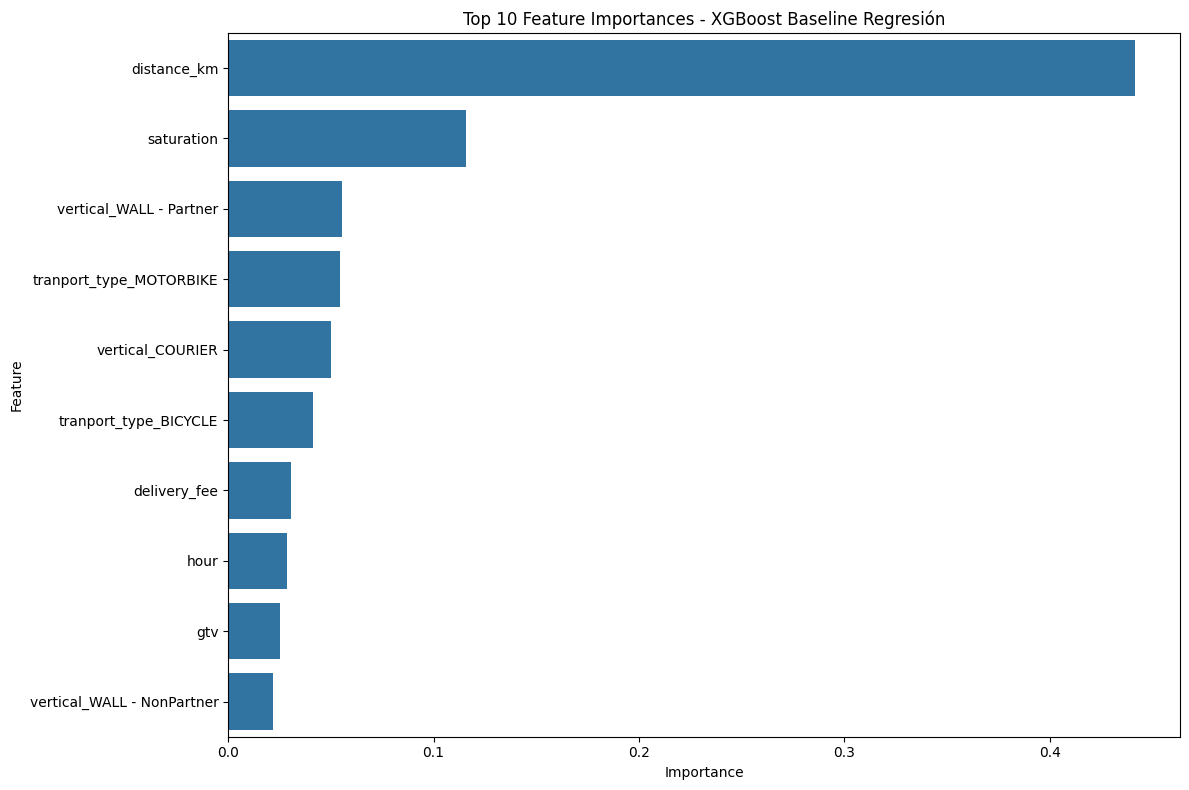

In [ ]:
# Obtenemos el modelo entrenado
model = best_xgb.named_steps['model']

# Nombres features
prep = best_xgb.named_steps['prep']

# Features generadas por OneHotEncoder
ohe_features = prep.named_transformers_['cat'].get_feature_names_out(cat_cols)

# Features numéricas + binarias que pasan por remainder='passthrough'
all_features = list(ohe_features) + num_cols + bin_cols

# Importancias
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importances
})

feat_imp = feat_imp.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=feat_imp.head(10),
    x='importance',
    y='feature'
)

plt.title('Top 10 Feature Importances - XGBoost Baseline Regresión')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [ ]:
top10_feat_imp = (
    feat_imp[['feature', 'importance']]
    .sort_values(by='importance', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10_feat_imp['importance'] = top10_feat_imp['importance'].round(4)

print(top10_feat_imp)

                      feature  importance
0                 distance_km      0.4413
1                  saturation      0.1157
2     vertical_WALL - Partner      0.0552
3     tranport_type_MOTORBIKE      0.0545
4            vertical_COURIER      0.0500
5       tranport_type_BICYCLE      0.0412
6                delivery_fee      0.0306
7                        hour      0.0289
8                         gtv      0.0252
9  vertical_WALL - NonPartner      0.0221


El modelo base de XGBoost muestra que las variables operativas son los principales drivers predictivos del problema.

En particular, la distancia domina claramente la capacidad predictiva,
seguida del nivel de saturación del sistema, mientras que factores estructurales como la vertical y el tipo de transporte aportan señales adicionales relevantes.

## **9. Clasificación de tiempos de entrega por rangos**

Además de evaluar el modelo como un problema de regresión, se realizó un análisis adicional discretizando los tiempos de entrega en intervalos temporales, con el objetivo de analizar el comportamiento del modelo desde una perspectiva más cercana a negocio y experiencia de usuario.

En aplicaciones reales de delivery, resulta más interpretable trabajar con rangos aproximados de ETA, por ejemplo “20–30 minutos”, en lugar de una predicción exacta al minuto.

**Distribución de clases**

En el análisis exploratorio inicial se observó que la mayoría de pedidos se concentran en las categorías centrales, especialmente entre 20 y 45 minutos, mientras que las clases extremas presentan una menor representación.

Esto introduce cierto desbalanceo, especialmente en los pedidos muy rápidos o muy largos, lo que puede dificultar la capacidad del modelo para aprender correctamente estos casos menos frecuentes.

### **9.1 Conversión de predicciones a categorías**

A partir de las predicciones continuas del modelo de regresión, se transformaron los tiempos estimados en categorías discretas:

In [ ]:
def clasificar_tiempo(x):
    if 5 <= x < 20:
        return 0
    elif 20 <= x < 30:
        return 1
    elif 30 <= x < 45:
        return 2
    elif 45 <= x < 60:
        return 3
    else:
        return 4

y_pred_class = pd.Series(y_pred, index=y_test.index).apply(clasificar_tiempo)
y_test_class = y_test.apply(clasificar_tiempo)

Posteriormente, se compararon las clases predichas frente a las clases reales mediante métricas de clasificación y matriz de confusión.

- **Classification report**

In [ ]:
print(classification_report(y_test_class, y_pred_class))

              precision    recall  f1-score   support

           0       0.51      0.02      0.03      1464
           1       0.49      0.63      0.56      4266
           2       0.55      0.64      0.59      4974
           3       0.41      0.33      0.36      1478
           4       0.62      0.28      0.39       536

    accuracy                           0.51     12718
   macro avg       0.52      0.38      0.39     12718
weighted avg       0.51      0.51      0.48     12718



En este contexto, la métrica más relevante no es únicamente la accuracy global, ya que las clases representan intervalos ordinales de tiempo y no categorías independientes sin relación entre ellas.

Por ello, resulta especialmente importante analizar:
- el recall de cada categoría
- el tipo de errores cometidos
- y la proximidad entre clases reales y predichas

El modelo obtiene su mejor rendimiento en las categorías centrales:
- 20–30 min
- 30–45 min

que además representan la mayoría de observaciones del dataset.

En cambio, las clases extremas muestran un recall considerablemente inferior, especialmente la clase de pedidos rápidos (<20 min), donde el modelo tiende a sobreestimar el tiempo de entrega.

Este comportamiento es coherente con el objetivo de negocio planteado previamente, donde infraestimar tiempos resulta más perjudicial que sobreestimarlos ligeramente.

- **Matriz de confusión**

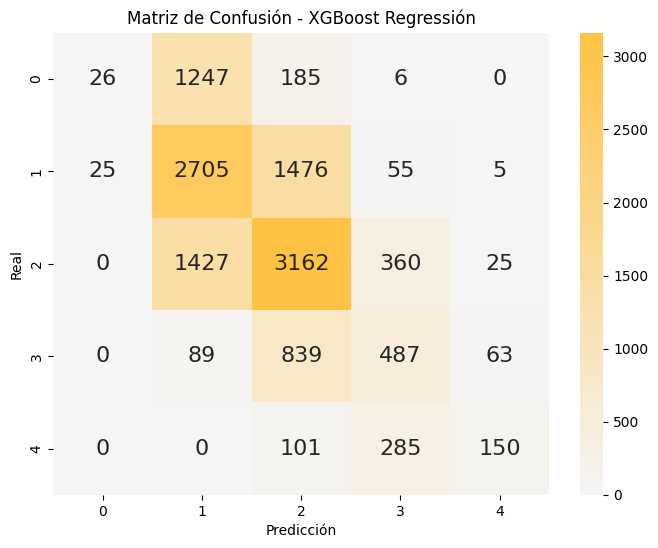

In [ ]:
GLOVO_COLORS = {
    "yellow":     "#FFC244",
    "gray_light": "#F5F5F5",
    "green":      "#00A082"
}

# Mapa de colores (Gris claro -> Amarillo Glovo)
glovo_cmap_yellow = LinearSegmentedColormap.from_list(
    "glovo_yellow", [GLOVO_COLORS["gray_light"], GLOVO_COLORS["yellow"]]
)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix_xgb,
    annot=True,
    fmt='d',
    cmap=glovo_cmap_yellow,
    annot_kws={"size": 16}
)

plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - XGBoost Regressión')
plt.show()

La matriz de confusión muestra un comportamiento razonablemente consistente del modelo.

La mayoría de errores se producen entre categorías adyacentes, por ejemplo:
- 20–30 min ↔ 30–45 min
- 30–45 min ↔ 45–60 min

lo que indica que el modelo mantiene una buena aproximación ordinal de los tiempos de entrega.

Resulta especialmente relevante que apenas se producen errores extremos, como predecir pedidos muy rápidos como extremadamente largos o viceversa. Esto sugiere que, aunque el modelo no siempre acierta el intervalo exacto, sí suele mantener predicciones cercanas al rango temporal real esperado.

## **10. Conclusiones**

El análisis por categorías confirma los resultados obtenidos previamente en regresión:

- el modelo captura adecuadamente el comportamiento general de los tiempos de entrega
- presenta mayor estabilidad en los rangos centrales más frecuentes
- y tiende a suavizar predicciones extremas

Desde una perspectiva de negocio, este comportamiento puede resultar incluso deseable, ya que reduce el riesgo de infraestimar tiempos de entrega y generar expectativas irreales al usuario final.

No obstante, el análisis de modelos, errores y de *feature importance* también sugiere que el rendimiento actual del modelo está parcialmente limitado por la información disponible en las variables utilizadas. Aunque el modelo consigue capturar correctamente los principales patrones operativos, todavía existe margen de mejora en escenarios más complejos o extremos, donde las features actuales parecen no aportar suficiente capacidad explicativa.

En particular, se observa que variables operativas como `distance_km` y `saturation` concentran gran parte de la capacidad predictiva del modelo, mientras que otras variables aportan información más limitada. Esto indica que el modelo depende fuertemente de un conjunto reducido de señales y que probablemente existan factores adicionales no representados en el dataset que afectan al comportamiento real de los tiempos de entrega.

Por ello, el siguiente paso natural del proyecto consiste en realizar una fase de *feature engineering*, orientada a incorporar variables más representativas del contexto operativo y temporal.